In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [2]:
# Imports & Paths
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


In [3]:
root_path = "/kaggle/input/chest-xray-pneumonia/chest_xray"

train_path = os.path.join(root_path, "train")
val_path   = os.path.join(root_path, "val")
test_path  = os.path.join(root_path, "test")

train_normal = os.path.join(train_path, "NORMAL")
train_pneumonia = os.path.join(train_path, "PNEUMONIA")


In [4]:
# Dataset Structure Check
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    for cls in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(root_path, split, cls)
        print(f"{cls}: {len(os.listdir(path))}")



TRAIN
NORMAL: 1341
PNEUMONIA: 3875

VAL
NORMAL: 8
PNEUMONIA: 8

TEST
NORMAL: 234
PNEUMONIA: 390


In [5]:
# Class Distribution Visualization
splits = ["train", "val", "test"]
counts = {"NORMAL": [], "PNEUMONIA": []}

for split in splits:
    for cls in ["NORMAL", "PNEUMONIA"]:
        counts[cls].append(len(os.listdir(os.path.join(root_path, split, cls))))

df_counts = pd.DataFrame(counts, index=splits)
df_counts


,NORMAL,PNEUMONIA
train,1341,3875
val,8,8
test,234,390


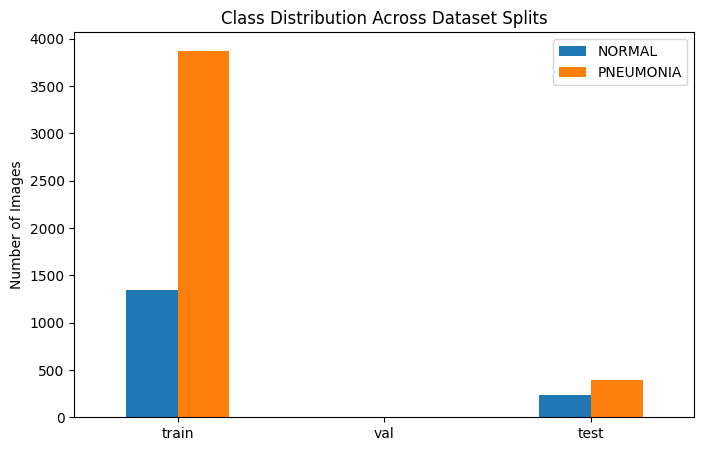

In [6]:
df_counts.plot(kind="bar", figsize=(8,5))
plt.title("Class Distribution Across Dataset Splits")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()


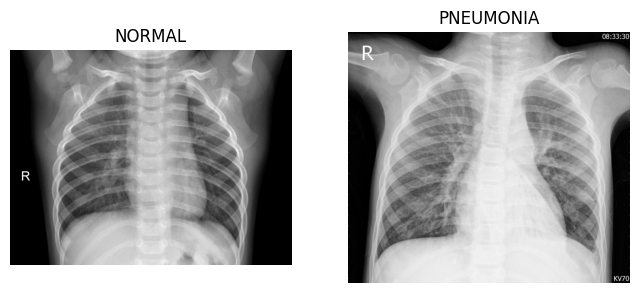

In [7]:
# Random Image Visualization (Sanity Check)
import random

normal_img = random.choice(os.listdir(train_normal))
pneumonia_img = random.choice(os.listdir(train_pneumonia))

img_normal = cv2.imread(os.path.join(train_normal, normal_img), cv2.IMREAD_GRAYSCALE)
img_pneumonia = cv2.imread(os.path.join(train_pneumonia, pneumonia_img), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img_normal, cmap="gray")
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_pneumonia, cmap="gray")
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()


In [8]:
# Image Size & Resolution Analysis
heights, widths = [], []

for img_name in tqdm(os.listdir(train_normal)):
    img = cv2.imread(os.path.join(train_normal, img_name), 0)
    if img is not None:
        h, w = img.shape
        heights.append(h)
        widths.append(w)

for img_name in tqdm(os.listdir(train_pneumonia)):
    img = cv2.imread(os.path.join(train_pneumonia, img_name), 0)
    if img is not None:
        h, w = img.shape
        heights.append(h)
        widths.append(w)


100%|██████████| 3875/3875 [00:42<00:00, 90.15it/s]


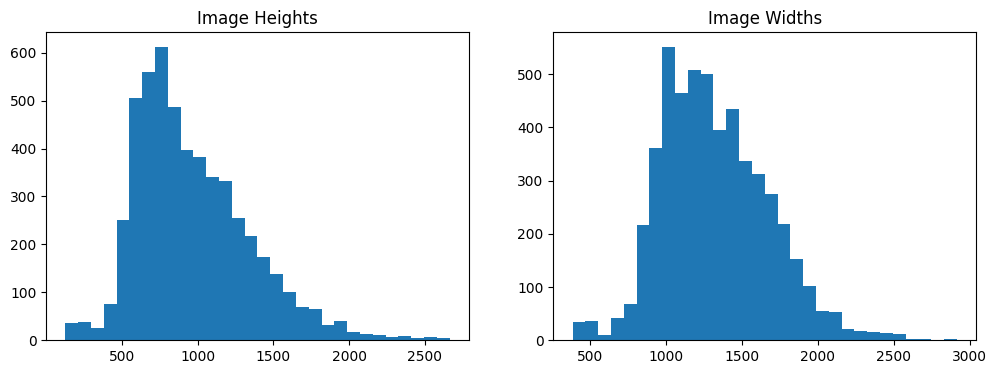

In [9]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(heights, bins=30)
plt.title("Image Heights")

plt.subplot(1,2,2)
plt.hist(widths, bins=30)
plt.title("Image Widths")

plt.show()
